--- Loading Results ---
 All result files loaded successfully.

1. GLOBAL PERFORMANCE SUMMARY
                   Metric CNN Baseline VLM SOTA Abs Improvement
         Overall Accuracy       58.90%   66.67%          +7.77%
           Macro F1-Score       0.1177   0.5694         +0.4517
Closed Questions (Yes/No)       67.39%   67.64%          +0.25%
   Open Questions (Other)        3.80%   60.33%         +56.52%
 Table saved to comparison_table.csv


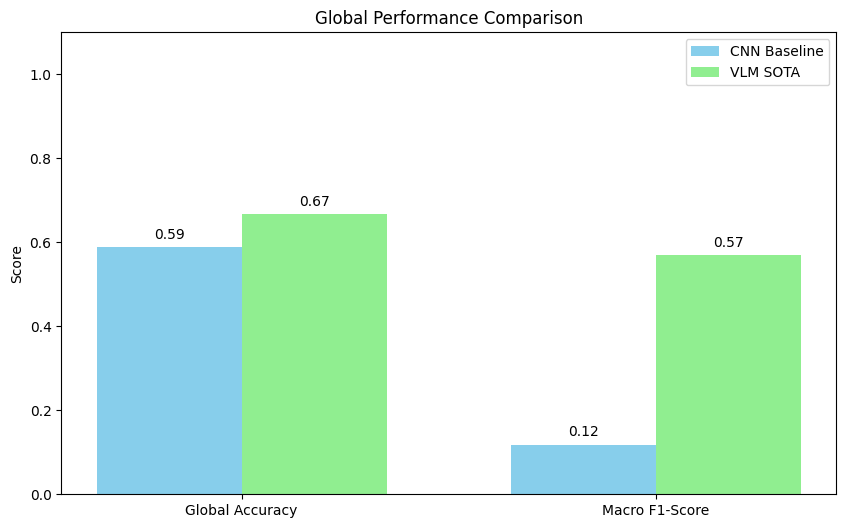

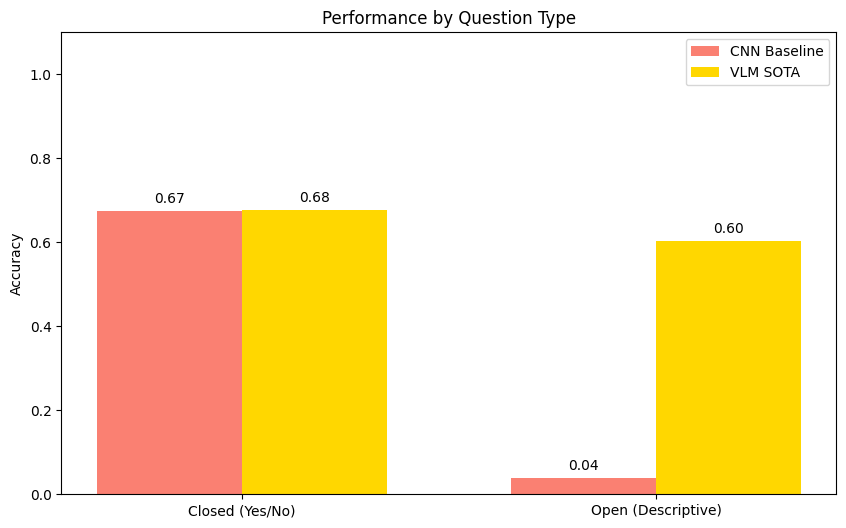


2. STATISTICAL SIGNIFICANCE (McNemar Test)

--- McNemar Contingency Table ---
             VLM Correct  VLM Wrong
CNN Correct          600        211
CNN Wrong            318        248
------------------------------
Statistic: 21.2401, P-Value: 4.0520e-06
 RESULT: Statistically Significant Improvement (p < 0.05)

3. COST / BENEFIT ANALYSIS
CNN: 24.98 ms/sample | 58.90% Acc
VLM: 13.40 ms/sample | 66.67% Acc
Slowdown Factor: 0.5x slower


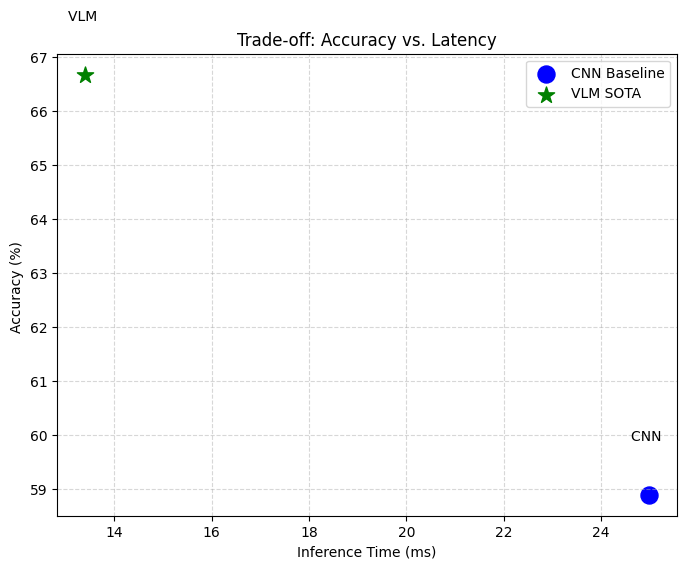


4. QUALITATIVE ANALYSIS (Visualizing VLM Wins)
Total VLM Wins : 318 samples.
Displaying 3 'Open-Ended' wins:


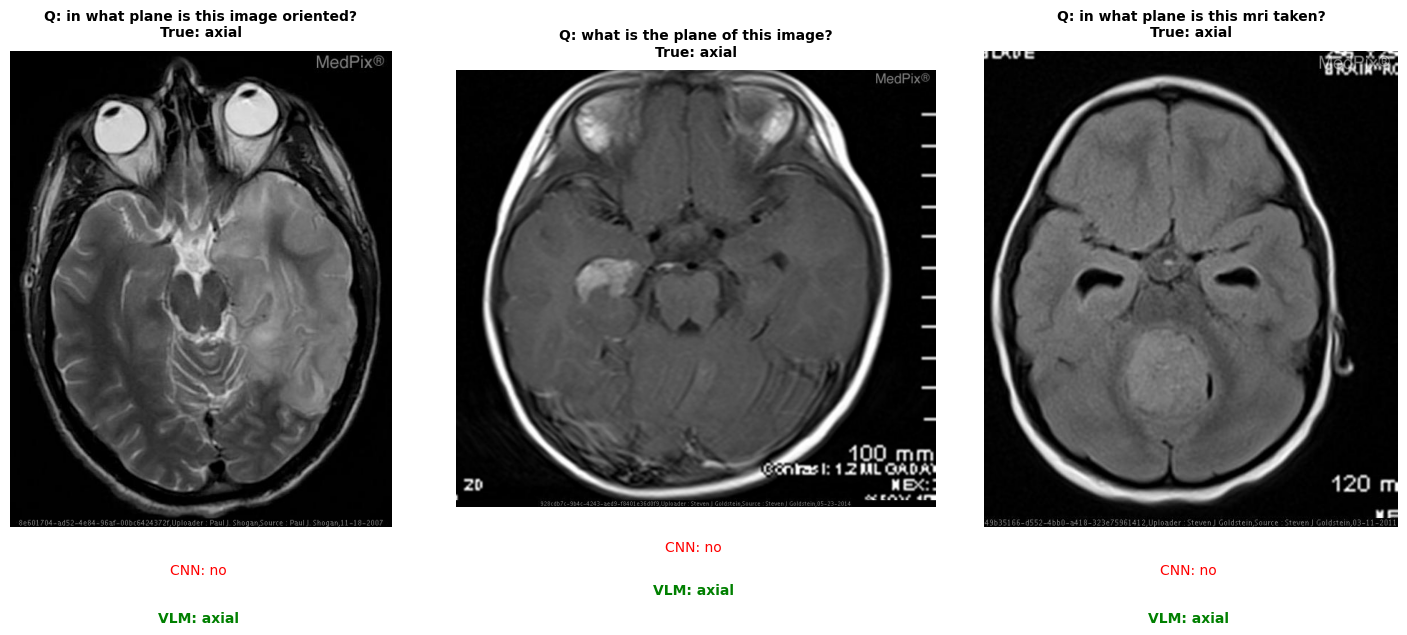


5. LEARNING CURVES COMPARISON


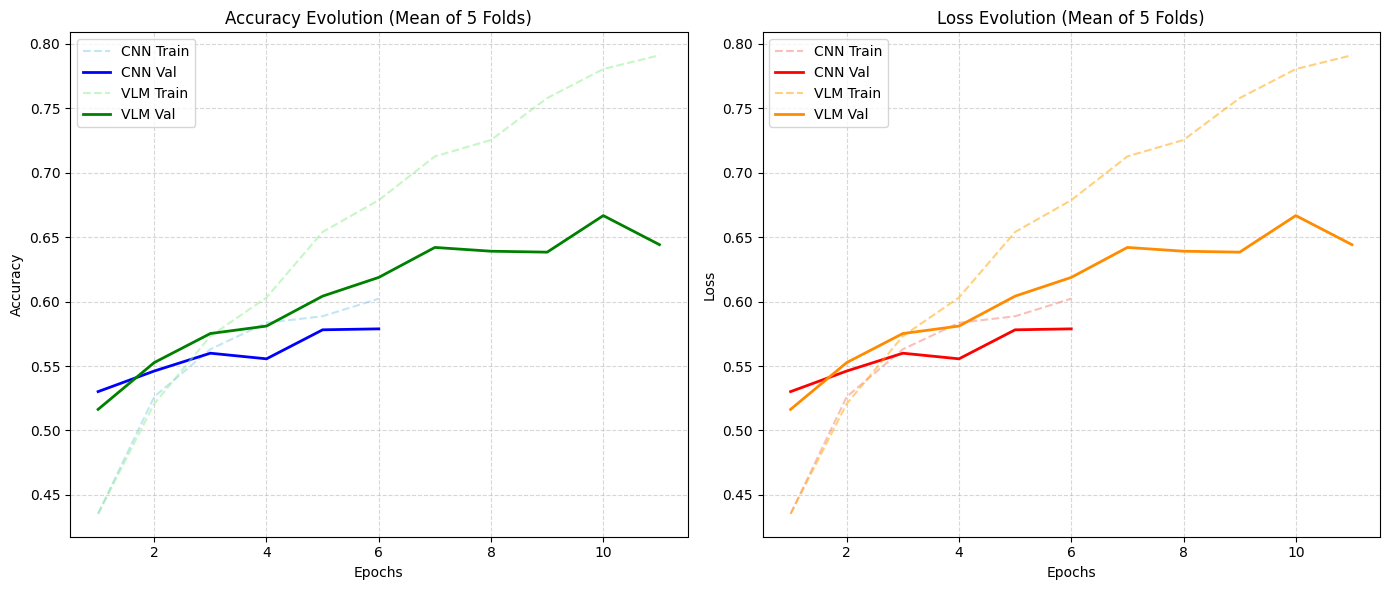

 Learning curves generated successfully.


In [ ]:
# DADDI ADDOUN Sami
# matrix n°:24223007
# CODE 3:  COMPARISON ANALYSIS (Metrics + Stats + Quali + Cost)


import pickle
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns
import pandas as pd
from statsmodels.stats.contingency_tables import mcnemar
import cv2

# --- CONFIGURATION ---
BASE_PATH = 'YOUR_PATH_TO_DATA'
IMAGE_PATH = os.path.join(BASE_PATH, 'VQA_RAD_Image_Folder')
RESULTS_PATH = 'YOUR_PATH_TO_RESULTS'

# Load  results (containing metadata/time)
CNN_FILE = os.path.join(RESULTS_PATH, 'cnn_results.pkl')
VLM_FILE = os.path.join(RESULTS_PATH, 'vlm_results.pkl')

def load_results(filepath):
    if not os.path.exists(filepath):
        print(f" Error: File {filepath} not found. Run Code 1 & 2 first.")
        return None
    with open(filepath, 'rb') as f:
        return pickle.load(f)

print("--- Loading Results ---")
cnn_res = load_results(CNN_FILE)
vlm_res = load_results(VLM_FILE)

if cnn_res and vlm_res:
    print(" All result files loaded successfully.")
    classes = cnn_res['classes']

    #  GLOBAL METRICS TABLE & CHARTS (The Basics)

    print("\n" + "="*60)
    print("1. GLOBAL PERFORMANCE SUMMARY")
    print("="*60)

    # A. Pandas Table
    comparison_df = pd.DataFrame({
        'Metric': [
            'Overall Accuracy',
            'Macro F1-Score',
            'Closed Questions (Yes/No)',
            'Open Questions (Other)'
        ],
        'CNN Baseline': [
            f"{cnn_res['accuracy']*100:.2f}%",
            f"{cnn_res['macro_f1']:.4f}",
            f"{cnn_res['acc_closed']*100:.2f}%",
            f"{cnn_res['acc_open']*100:.2f}%"
        ],
        'VLM SOTA': [
            f"{vlm_res['accuracy']*100:.2f}%",
            f"{vlm_res['macro_f1']:.4f}",
            f"{vlm_res['acc_closed']*100:.2f}%",
            f"{vlm_res['acc_open']*100:.2f}%"
        ],
        'Abs Improvement': [
            f"{(vlm_res['accuracy'] - cnn_res['accuracy'])*100:+.2f}%",
            f"{(vlm_res['macro_f1'] - cnn_res['macro_f1']):+.4f}",
            f"{(vlm_res['acc_closed'] - cnn_res['acc_closed'])*100:+.2f}%",
            f"{(vlm_res['acc_open'] - cnn_res['acc_open'])*100:+.2f}%"
        ]
    })

    print(comparison_df.to_string(index=False))
    comparison_df.to_csv(os.path.join(RESULTS_PATH, 'comparison_table.csv'), index=False)
    print(" Table saved to comparison_table.csv")

    # B. Global Metrics Bar Chart
    metrics = ['Global Accuracy', 'Macro F1-Score']
    cnn_vals = [cnn_res['accuracy'], cnn_res['macro_f1']]
    vlm_vals = [vlm_res['accuracy'], vlm_res['macro_f1']]

    x = np.arange(len(metrics))
    width = 0.35

    plt.figure(figsize=(10, 6))
    plt.bar(x - width/2, cnn_vals, width, label='CNN Baseline', color='skyblue')
    plt.bar(x + width/2, vlm_vals, width, label='VLM SOTA', color='lightgreen')
    plt.ylabel('Score')
    plt.title('Global Performance Comparison')
    plt.xticks(x, metrics)
    plt.ylim(0, 1.1)
    plt.legend()

    for i, v in enumerate(cnn_vals): plt.text(i - width/2, v + 0.02, f"{v:.2f}", ha='center')
    for i, v in enumerate(vlm_vals): plt.text(i + width/2, v + 0.02, f"{v:.2f}", ha='center')

    plt.savefig(os.path.join(RESULTS_PATH, 'comparison_global_metrics.png'))
    plt.show()

    # C. Question Type Bar Chart
    types = ['Closed (Yes/No)', 'Open (Descriptive)']
    cnn_types = [cnn_res['acc_closed'], cnn_res['acc_open']]
    vlm_types = [vlm_res['acc_closed'], vlm_res['acc_open']]

    x = np.arange(len(types))

    plt.figure(figsize=(10, 6))
    plt.bar(x - width/2, cnn_types, width, label='CNN Baseline', color='salmon')
    plt.bar(x + width/2, vlm_types, width, label='VLM SOTA', color='gold')
    plt.ylabel('Accuracy')
    plt.title('Performance by Question Type')
    plt.xticks(x, types)
    plt.ylim(0, 1.1)
    plt.legend()

    for i, v in enumerate(cnn_types): plt.text(i - width/2, v + 0.02, f"{v:.2f}", ha='center')
    for i, v in enumerate(vlm_types): plt.text(i + width/2, v + 0.02, f"{v:.2f}", ha='center')

    plt.savefig(os.path.join(RESULTS_PATH, 'comparison_question_types.png'))
    plt.show()


    #  STATISTICAL SIGNIFICANCE (McNemar)

    print("\n" + "="*60)
    print("2. STATISTICAL SIGNIFICANCE (McNemar Test)")
    print("="*60)

    y_true = np.array(cnn_res['all_true'])
    cnn_pred = np.array(cnn_res['all_pred'])
    vlm_pred = np.array(vlm_res['all_pred'])

    cnn_correct = (cnn_pred == y_true)
    vlm_correct = (vlm_pred == y_true)

    # Contingency Table
    a = np.sum(cnn_correct & vlm_correct)   # Both Correct
    b = np.sum(cnn_correct & ~vlm_correct)  # CNN Correct, VLM Wrong
    c = np.sum(~cnn_correct & vlm_correct)  # CNN Wrong, VLM Correct (Improvements)
    d = np.sum(~cnn_correct & ~vlm_correct) # Both Wrong

    contingency_table = [[a, b], [c, d]]
    df_contingency = pd.DataFrame(contingency_table,
                                  columns=['VLM Correct', 'VLM Wrong'],
                                  index=['CNN Correct', 'CNN Wrong'])

    print("\n--- McNemar Contingency Table ---")
    print(df_contingency)
    print("-" * 30)

    result = mcnemar(contingency_table, exact=False, correction=True)
    print(f"Statistic: {result.statistic:.4f}, P-Value: {result.pvalue:.4e}")

    if result.pvalue < 0.05:
        print(" RESULT: Statistically Significant Improvement (p < 0.05)")
    else:
        print(" RESULT: Not Statistically Significant")

    #  COST / BENEFIT ANALYSIS

    print("\n" + "="*60)
    print("3. COST / BENEFIT ANALYSIS")
    print("="*60)

    time_cnn = cnn_res['inference_time_ms']
    time_vlm = vlm_res['inference_time_ms']
    acc_cnn = cnn_res['accuracy'] * 100
    acc_vlm = vlm_res['accuracy'] * 100

    print(f"CNN: {time_cnn:.2f} ms/sample | {acc_cnn:.2f}% Acc")
    print(f"VLM: {time_vlm:.2f} ms/sample | {acc_vlm:.2f}% Acc")
    print(f"Slowdown Factor: {time_vlm/time_cnn:.1f}x slower")

    # Trade-off Plot
    plt.figure(figsize=(8, 6))
    plt.scatter(time_cnn, acc_cnn, color='blue', s=150, label='CNN Baseline', marker='o')
    plt.scatter(time_vlm, acc_vlm, color='green', s=150, label='VLM SOTA', marker='*')

    plt.text(time_cnn, acc_cnn+1, 'CNN ', ha='center')
    plt.text(time_vlm, acc_vlm+1, 'VLM ', ha='center')

    plt.xlabel('Inference Time (ms)')
    plt.ylabel('Accuracy (%) ')
    plt.title('Trade-off: Accuracy vs. Latency')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.savefig(os.path.join(RESULTS_PATH, 'cost_benefit_tradeoff.png'))
    plt.show()


    # QUALITATIVE ANALYSIS (Visualizing Wins)

    print("\n" + "="*60)
    print("4. QUALITATIVE ANALYSIS (Visualizing VLM Wins)")
    print("="*60)

    # Identify cases: CNN Wrong & VLM Correct
    indices_wins = np.where((~cnn_correct) & vlm_correct)[0]
    print(f"Total VLM Wins : {len(indices_wins)} samples.")

    # Filter for Open-Ended questions to show "intelligence"
    interesting_indices = []
    for idx in indices_wins:
        ans_idx = y_true[idx]
        ans_str = classes[ans_idx]
        if ans_str not in ['yes', 'no']:
            interesting_indices.append(idx)

    print(f"Displaying {min(3, len(interesting_indices))} 'Open-Ended' wins:")

    if len(interesting_indices) > 0:
        plt.figure(figsize=(15, 6))
        for i, idx in enumerate(interesting_indices[:3]):
            fname = cnn_res['filenames'][idx]
            q_text = cnn_res['questions'][idx]

            true_lbl = classes[y_true[idx]]
            cnn_lbl = classes[cnn_pred[idx]]
            vlm_lbl = classes[vlm_pred[idx]]

            img_path = os.path.join(IMAGE_PATH, fname)
            img = cv2.imread(img_path)

            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                plt.subplot(1, 3, i+1)
                plt.imshow(img)
                plt.axis('off')

                # Title formatting
                title_text = f"Q: {q_text}\nTrue: {true_lbl}"
                plt.title(title_text, fontsize=10, fontweight='bold', pad=10)

                # Predictions below image
                plt.text(0.5, -0.1, f"CNN: {cnn_lbl} ",
                         transform=plt.gca().transAxes, ha='center', color='red')
                plt.text(0.5, -0.2, f"VLM: {vlm_lbl} ",
                         transform=plt.gca().transAxes, ha='center', color='green', fontweight='bold')
            else:
                print(f" Could not load image: {img_path}")

        plt.tight_layout()
        plt.savefig(os.path.join(RESULTS_PATH, 'qualitative_analysis_wins.png'))
        plt.show()
    else:
        print("No open-ended wins found to display.")


    #  LEARNING CURVES COMPARISON (Train vs Val)
    print("\n" + "="*60)
    print("5. LEARNING CURVES COMPARISON")
    print("="*60)

    def plot_history(histories, title, color_train, color_val):
        # We take the minimum number of epochs across folds to ensure alignment
        min_epochs = min([len(h['accuracy']) for h in histories])

        # Average Accuracy
        acc_train = np.mean([h['accuracy'][:min_epochs] for h in histories], axis=0)
        acc_val = np.mean([h['val_accuracy'][:min_epochs] for h in histories], axis=0)

        # Average Loss
        loss_train = np.mean([h['loss'][:min_epochs] for h in histories], axis=0)
        loss_val = np.mean([h['val_loss'][:min_epochs] for h in histories], axis=0)

        epochs = range(1, min_epochs + 1)

        # Plot Accuracy
        plt.plot(epochs, acc_train, '--', color=color_train, alpha=0.5, label=f'{title} Train')
        plt.plot(epochs, acc_val, '-', color=color_val, linewidth=2, label=f'{title} Val')

    # Check if history exists in the loaded files
    if 'history' in cnn_res and 'history' in vlm_res:
        plt.figure(figsize=(14, 6))

        # 1. Accuracy Comparison
        plt.subplot(1, 2, 1)
        plot_history(cnn_res['history'], 'CNN', 'skyblue', 'blue')
        plot_history(vlm_res['history'], 'VLM', 'lightgreen', 'green')
        plt.title('Accuracy Evolution (Mean of 5 Folds)')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)

        # 2. Loss Comparison
        plt.subplot(1, 2, 2)
        plot_history(cnn_res['history'], 'CNN', 'salmon', 'red')
        plot_history(vlm_res['history'], 'VLM', 'orange', 'darkorange')
        plt.title('Loss Evolution (Mean of 5 Folds)')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)

        plt.tight_layout()
        plt.savefig(os.path.join(RESULTS_PATH, 'comparison_learning_curves.png'))
        plt.show()
        print(" Learning curves generated successfully.")
    else:
        print(" No history found in .pkl files. Please re-run Code 1 & 2 with the 'history' save enabled.")
else:
    print(" Missing Result Files. Please run Code 1 and Code 2 (V2 Versions) first.")